In [2]:
import pandas as pd

df = pd.read_csv('data/raw/accepted_2007_to_2018Q4.csv', low_memory=False)

print(df.shape)
print(df.dtypes)
df.head()

(2260701, 151)
id                        object
member_id                float64
loan_amnt                float64
funded_amnt              float64
funded_amnt_inv          float64
                          ...   
settlement_status         object
settlement_date           object
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
Length: 151, dtype: object


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Colonnes liées aux dates
date_cols = [col for col in df.columns if 'date' in col.lower() or 'issue' in col.lower()]
print("Date columns:", date_cols)

# Colonnes liées au statut
status_cols = [col for col in df.columns if 'status' in col.lower() or 'default' in col.lower()]
print("Status columns:", status_cols)

# Valeurs uniques du statut de prêt
print("\nloan_status values:")
print(df['loan_status'].value_counts())

Date columns: ['issue_d', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'debt_settlement_flag_date', 'settlement_date']
Status columns: ['verification_status', 'loan_status', 'initial_list_status', 'verification_status_joint', 'hardship_status', 'hardship_loan_status', 'settlement_status']

loan_status values:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [4]:
# Parser la date pour tout le monde d'abord
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['vintage'] = df['issue_d'].dt.to_period('Q')

# DF 1 — pour le calcul de default rate (outcomes connus seulement)
df_completed = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_completed['is_default'] = (df_completed['loan_status'] == 'Charged Off').astype(int)

# DF 2 — pour les analyses comportementales (tout le portfolio)
df_portfolio = df.copy()

print("Completed loans:", df_completed.shape)
print("Full portfolio:", df_portfolio.shape)

Completed loans: (1345310, 153)
Full portfolio: (2260701, 152)


In [5]:
date_cols = [col for col in df.columns if 'date' in col.lower() or 'pymnt' in col.lower()]
print(date_cols)

['pymnt_plan', 'total_pymnt', 'total_pymnt_inv', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'debt_settlement_flag_date', 'settlement_date']


In [ ]:
import pandas as pd

df_completed['last_pymnt_d'] = pd.to_datetime(df_completed['last_pymnt_d'], format='%b-%Y')


In [16]:
df_completed['last_pymnt_d'] = pd.to_datetime(df_completed['last_pymnt_d'], format='%b-%Y')
df_completed['term_months'] = df_completed['term'].str.strip().str.extract('(\d+)').astype(int)
df_completed['loan_duration_months'] = (
    (df_completed['last_pymnt_d'].dt.year - df_completed['issue_d'].dt.year) * 12 +
    (df_completed['last_pymnt_d'].dt.month - df_completed['issue_d'].dt.month)
)
df_completed['is_prepaid'] = (
    (df_completed['loan_status'] == 'Fully Paid') &
    (df_completed['loan_duration_months'] < df_completed['term_months'] - 3)
).astype(int)

print(df_completed['is_prepaid'].value_counts())
print(f"Prepayment rate: {df_completed['is_prepaid'].mean():.1%}")

is_prepaid
1    804995
0    540315
Name: count, dtype: int64
Prepayment rate: 59.8%


In [18]:
df_completed['last_pymnt_d'].max()


Timestamp('2019-03-01 00:00:00')

In [19]:
df_completed[df_completed['is_default'] == 1].columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [20]:
df_completed[df_completed['is_default'] == 1]['last_pymnt_d'].describe()

count                           266246
mean     2016-12-04 23:12:59.666924544
min                2008-03-01 00:00:00
25%                2016-03-01 00:00:00
50%                2017-03-01 00:00:00
75%                2018-01-01 00:00:00
max                2019-03-01 00:00:00
Name: last_pymnt_d, dtype: object

In [21]:
df_completed['months_to_default'] = None

mask_default = df_completed['is_default'] == 1
df_completed.loc[mask_default, 'months_to_default'] = (
    (df_completed.loc[mask_default, 'last_pymnt_d'].dt.year - 
     df_completed.loc[mask_default, 'issue_d'].dt.year) * 12 +
    (df_completed.loc[mask_default, 'last_pymnt_d'].dt.month - 
     df_completed.loc[mask_default, 'issue_d'].dt.month)
)

def vintage_default_rate(df, horizon):
    total = df.groupby('vintage')['is_default'].count()
    defaulted = df[
        (df['is_default'] == 1) & 
        (df['months_to_default'] <= horizon)
    ].groupby('vintage')['is_default'].count()
    return (defaulted / total).fillna(0).rename(f'dr_{horizon}m')

dr_12 = vintage_default_rate(df_completed, 12)
dr_24 = vintage_default_rate(df_completed, 24)
dr_36 = vintage_default_rate(df_completed, 36)

vintage_curves = pd.concat([dr_12, dr_24, dr_36], axis=1)
print(vintage_curves.head(10))

           dr_12m    dr_24m    dr_36m
vintage                              
2007Q2   0.000000  0.000000  0.000000
2007Q3   0.012346  0.061728  0.123457
2007Q4   0.059172  0.153846  0.195266
2008Q1   0.051635  0.127367  0.163511
2008Q2   0.054795  0.130137  0.150685
2008Q3   0.059140  0.145161  0.150538
2008Q4   0.067594  0.131213  0.153082
2009Q1   0.051613  0.096774  0.117419
2009Q2   0.051813  0.102591  0.125389
2009Q3   0.044679  0.089358  0.111292


In [22]:
df_completed[df_completed['vintage'] == '2007Q2'].shape

(1, 157)

In [25]:
pip install matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


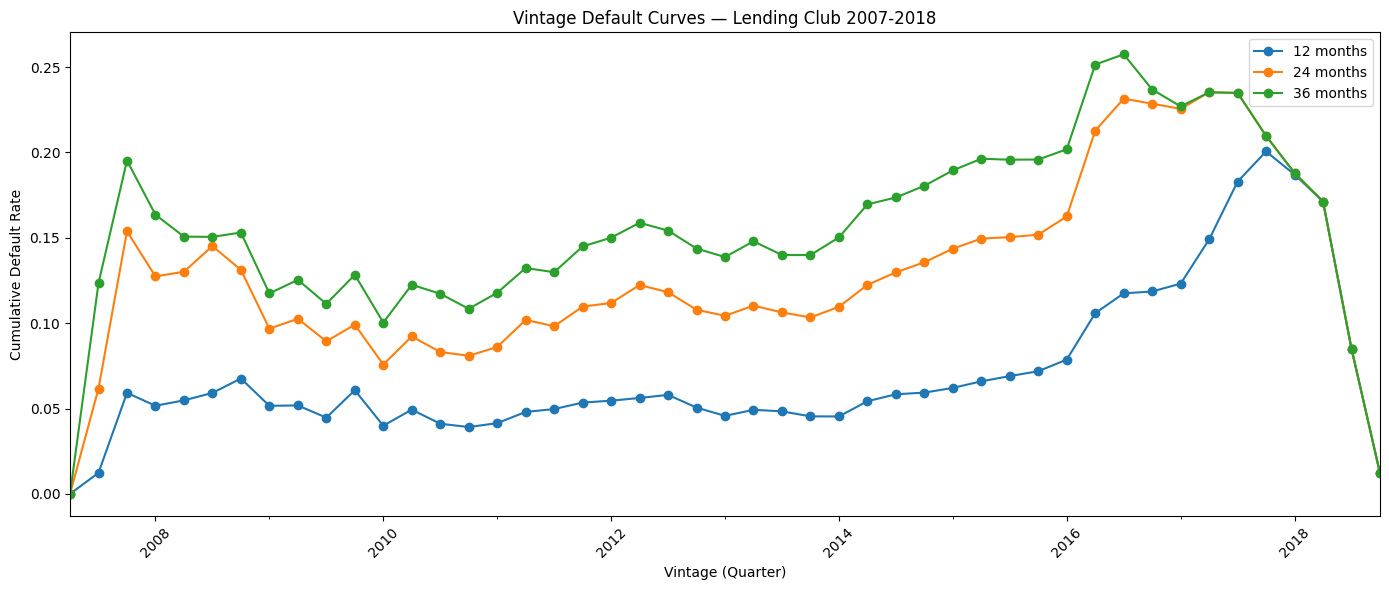

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

vintage_curves['dr_12m'].plot(ax=ax, marker='o', label='12 months')
vintage_curves['dr_24m'].plot(ax=ax, marker='o', label='24 months')
vintage_curves['dr_36m'].plot(ax=ax, marker='o', label='36 months')

ax.set_title('Vintage Default Curves — Lending Club 2007-2018')
ax.set_ylabel('Cumulative Default Rate')
ax.set_xlabel('Vintage (Quarter)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

/var/folders/hm/xftnhcws49j4mdwg3vpc5zfc0000gn/T/ipykernel_60716/482393042.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vintage_curves_by_grade = df_completed.groupby(['vintage', 'grade']).apply(


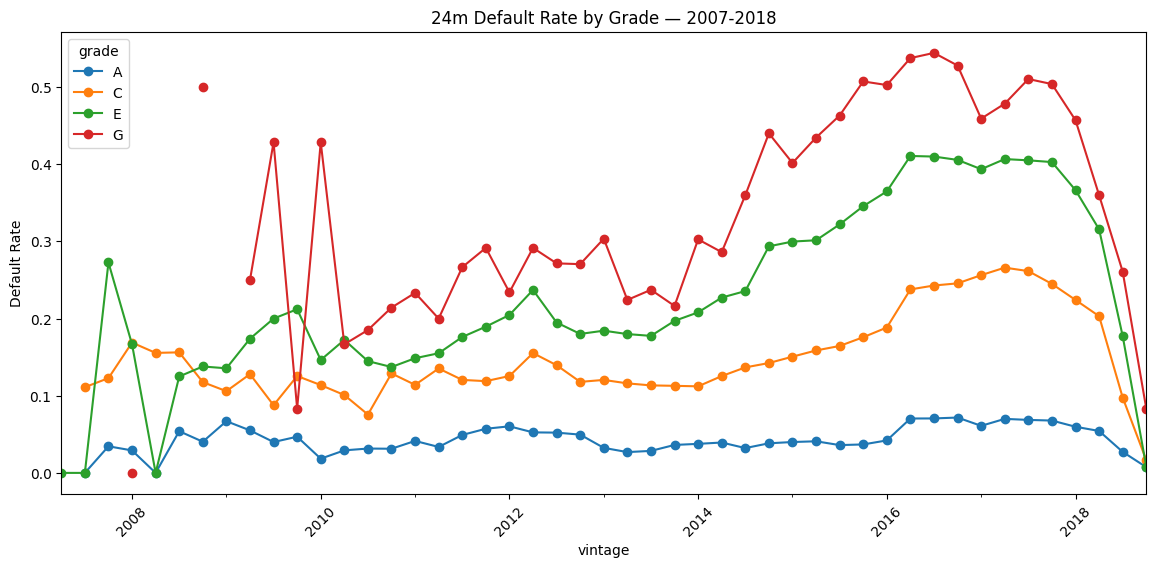

In [27]:
vintage_curves_by_grade = df_completed.groupby(['vintage', 'grade']).apply(
    lambda x: pd.Series({
        'dr_24m': ((x['is_default'] == 1) & (x['months_to_default'] <= 24)).sum() / len(x)
    })
).unstack('grade')

vintage_curves_by_grade['dr_24m'][['A', 'C', 'E', 'G']].plot(figsize=(14, 6), marker='o')
plt.title('24m Default Rate by Grade — 2007-2018')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

In [28]:
features_psi = ['fico_range_low', 'annual_inc', 'dti']

for f in features_psi:
    print(f)
    print(df_completed[f].describe())
    print()

fico_range_low
count    1.345310e+06
mean     6.961850e+02
std      3.185251e+01
min      6.250000e+02
25%      6.700000e+02
50%      6.900000e+02
75%      7.100000e+02
max      8.450000e+02
Name: fico_range_low, dtype: float64

annual_inc
count    1.345310e+06
mean     7.624764e+04
std      6.992510e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

dti
count    1.344936e+06
mean     1.828267e+01
std      1.116045e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64



In [29]:
print(df_completed['annual_inc'].quantile(0.90))
print(df_completed['dti'].quantile(0.90))

125000.0
29.78


In [30]:
df_completed['annual_inc_capped'] = df_completed['annual_inc'].clip(0, 125000)
df_completed['dti_capped'] = df_completed['dti'].clip(0, 29.78)

In [31]:
pip install numpy


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Eviter division par zero
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)
    
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

import numpy as np

reference = df_completed[df_completed['issue_d'].dt.year.isin([2013, 2014])]

psi_results = []
for year in range(2015, 2019):
    sample = df_completed[df_completed['issue_d'].dt.year == year]
    for feature in ['fico_range_low', 'annual_inc_capped', 'dti_capped']:
        psi = calculate_psi(
            reference[feature].dropna().values,
            sample[feature].dropna().values
        )
        psi_results.append({'year': year, 'feature': feature, 'psi': psi})

psi_df = pd.DataFrame(psi_results)
print(psi_df.pivot(index='year', columns='feature', values='psi').round(3))

feature  annual_inc_capped  dti_capped  fico_range_low
year                                                  
2015                 0.002       0.030           0.003
2016                 0.008       0.022           0.008
2017                 0.012       0.016           0.039
2018                 0.017       0.058           0.192


In [34]:
# Dans ton notebook
vintage_curves.to_csv('data/processed/vintage_curves.csv')
psi_df.to_csv('data/processed/psi_results.csv', index=False)

vintage_by_grade = df_completed.groupby(['vintage', 'grade']).apply(
    lambda x: pd.Series({
        'dr_12m': ((x['is_default'] == 1) & (x['months_to_default'] <= 12)).sum() / len(x),
        'dr_24m': ((x['is_default'] == 1) & (x['months_to_default'] <= 24)).sum() / len(x),
        'dr_36m': ((x['is_default'] == 1) & (x['months_to_default'] <= 36)).sum() / len(x),
        'prepayment_rate': x['is_prepaid'].mean(),
        'loan_count': len(x)
    })
).reset_index()
vintage_by_grade.to_csv('data/processed/vintage_by_grade.csv', index=False)

/var/folders/hm/xftnhcws49j4mdwg3vpc5zfc0000gn/T/ipykernel_60716/2303930020.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vintage_by_grade = df_completed.groupby(['vintage', 'grade']).apply(
